## $f(x)=\sum c_i M_i(x_i)$ 黑盒优化


In [1]:
from dataclasses import dataclass, replace
from numbers import Integral, Real
from typing import Any, Protocol, Literal, Callable, Iterable, overload, cast
from numpy.typing import ArrayLike, NDArray
import scipy.signal as sps
import numpy as np

Sign = Literal["positive", "negative"]
Array = NDArray[np.float64]


class Optimizer(Protocol):
    def init(self): ...


In [14]:
def _finite_scalar(name: str, value: float, *, positive: bool = False):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, Real):
        raise TypeError(f"{name} must be a real scalar")
    if not np.isfinite(value) or (positive and value <= 0):
        raise ValueError(f"{name} must be finite" + (" and > 0" if positive else ""))


@dataclass(frozen=True)
class Term:
    sign: Sign
    b: float
    k: int
    n: int
    s: float
    p: float
    c: float = 1.0

    def __post_init__(self):
        if self.sign not in ("positive", "negative", "negtive"):
            raise ValueError("sign must be positive, negative, or negtive")
        for name, minimum in (("k", 0), ("n", 1)):
            value = getattr(self, name)
            if isinstance(value, (bool, np.bool_)) or not isinstance(value, Integral):
                raise TypeError(f"{name} must be an integer")
            if value < minimum:
                raise ValueError(f"{name} must be >= {minimum}")
        for name in ("b", "c", "s", "p"):
            _finite_scalar(name, getattr(self, name), positive=name in ("s", "p"))


def _image(image: Array) -> Array:
    image = np.asarray(image)
    if image.ndim != 2 or not np.issubdtype(image.dtype, np.floating):
        raise ValueError("image must be a two-dimensional floating-point array")
    if image.size == 0 or not np.all(np.isfinite(image)):
        raise ValueError("image must be nonempty and finite")
    return np.asarray(image, dtype=np.float64)


def _weights(values, count: int) -> Array:
    raw = np.asarray(values)
    if raw.dtype.kind not in "fiu":
        raise ValueError("weights must be real numbers")
    result = np.asarray(raw, dtype=np.float64)
    if result.shape != (count,) or not np.all(np.isfinite(result)):
        raise ValueError(f"weights must be a finite vector of length {count}")
    return result.copy()

In [15]:
def guass_kernel(s: float, p: float) -> Array:
    _finite_scalar("s", s, positive=True)
    _finite_scalar("p", p, positive=True)
    radius = int(np.ceil(p * s))

    x = np.arange(-radius, radius + 1)
    y = np.arange(-radius, radius + 1)

    X, Y = np.meshgrid(x, y)

    G = np.exp(-(X**2 + Y**2) / (2 * s**2))
    G /= G.sum()
    return G

In [16]:
def resist_term(
    image: Array,
    sign: Sign,
    b: float,
    k: int,
    n: int,
    s: float,
    p: float,
    make_Ib: Callable[[Array, float, Sign], Array],
    make_G: Callable[[float, float], Array],
):
    Term(sign, b, k, n, s, p)  # Also validate direct calls.
    image = _image(image)
    if k > 0 and min(image.shape) < 2:
        raise ValueError("gradient terms require both image dimensions >= 2")
    Ib = _image(make_Ib(image.copy(), b, sign))
    if Ib.shape != image.shape:
        raise ValueError("make_Ib must preserve image shape")

    def nabala_k(image: Array, k: int) -> Array:
        result = image
        for _ in range(k):
            dx, dy = np.gradient(result)
            result = np.abs(dx**2 + dy**2)

        return result

    grad = nabala_k(Ib, k)
    powered = grad**n
    kernel = make_G(s, p)
    conv = sps.fftconvolve(powered, kernel, mode="same")
    return np.maximum(conv, 0) ** (1.0 / n)

### 构建与增量调参

`build` 复制 Term 配置；`terms` 和 `weights` 返回独立快照。候选权重仅用于当前计算，
`set_weights` 才会提交权重。权重允许负数，不在模型内添加约束。

In [17]:
class ResistModel:
    def __init__(self, terms: Iterable[Term], *, make_Ib, make_G):
        self._terms = tuple(replace(term) for term in terms)
        self._make_Ib = make_Ib
        self._make_G = make_G

    @property
    def terms(self) -> tuple[Term, ...]:
        return tuple(replace(term) for term in self._terms)

    @property
    def weights(self) -> Array:
        return np.array([term.c for term in self._terms], dtype=np.float64)

    def update_term(self, index: int, **changes) -> None:
        if isinstance(index, (bool, np.bool_)) or not isinstance(index, Integral):
            raise TypeError("index must be an integer")
        if not 0 <= index < len(self._terms):
            raise IndexError("term index out of range")
        updated = replace(self._terms[index], **changes)
        terms = list(self._terms)
        terms[index] = updated
        self._terms = tuple(terms)

    def set_weights(self, c) -> None:
        weights = _weights(c, len(self._terms))
        self._terms = tuple(replace(term, c=float(w))
                            for term, w in zip(self._terms, weights))

    def _responses(self, image: Array) -> Array:
        image = _image(image).copy()
        if not self._terms:
            return np.empty((0, *image.shape), dtype=np.float64)
        responses = np.stack([
            resist_term(image, term.sign, term.b, term.k, term.n, term.s, term.p,
                        self._make_Ib, self._make_G)
            for term in self._terms
        ])
        if responses.shape != (len(self._terms), *image.shape):
            raise ValueError("term responses must preserve image shape")
        if not np.all(np.isfinite(responses)):
            raise ValueError("term responses must be finite")
        return responses

    def __call__(self, image: Array, *, weights=None) -> Array:
        c = self.weights if weights is None else _weights(weights, len(self._terms))
        return np.tensordot(c, self._responses(image), axes=(0, 0))

    def make_objective(
        self, image: Array, gauge_residuals: Callable[[Array], Array]
    ) -> Callable[[Array], float]:
        """Freeze term responses; return an optimizer-compatible RMS(c).

        gauge_residuals returns a nonempty finite 1-D real residual vector.
        Keep its gauge definitions/targets fixed during optimization; callback
        state is owned by the caller and is not copied.
        """
        if not self._terms:
            raise ValueError("a weight objective requires at least one term")
        responses = self._responses(image)
        responses.setflags(write=False)
        count = responses.shape[0]

        def objective(c: Array) -> float:
            weights = _weights(c, count)
            prediction = np.tensordot(weights, responses, axes=(0, 0))
            if not np.all(np.isfinite(prediction)):
                raise ValueError("prediction must be finite")
            raw = np.asarray(gauge_residuals(prediction))
            if raw.dtype.kind not in "fiu" or raw.ndim != 1 or raw.size == 0:
                raise ValueError("gauge residuals must be a nonempty real 1-D vector")
            residuals = np.asarray(raw, dtype=np.float64)
            if not np.all(np.isfinite(residuals)):
                raise ValueError("gauge residuals must be finite")
            # Equivalent to sqrt(mean(r**2)), without overflow when squaring.
            scale = float(np.max(np.abs(residuals)))
            return scale * float(np.sqrt(np.mean((residuals / scale)**2))) if scale else 0.0

        return objective


def build(
    terms: Iterable[Term], *,
    make_Ib: Callable[[Array, float, Sign], Array],
    make_G: Callable[[float, float], Array] = guass_kernel,
) -> ResistModel:
    return ResistModel(terms, make_Ib=make_Ib, make_G=make_G)

### 示例：构建与权重更新

下面的 `demo_make_Ib` 仅用于演示接口，不是工艺标定公式。
完整的 cutline CD 测量及 RMS 示例见后面的“50 项理想模型”部分。


In [18]:
def demo_make_Ib(image: Array, b: float, sign: Sign) -> Array:
    return np.maximum(image - b if sign == "positive" else b - image, 0.0)


terms = [
    Term("positive", b=0.2, k=0, n=1, s=1.0, p=3.0, c=1.0),
    Term("negative", b=0.8, k=0, n=1, s=1.5, p=3.0, c=0.5),
]
simulate = build(terms, make_Ib=demo_make_Ib)
image = np.linspace(0.0, 1.0, 64).reshape(8, 8)
result = simulate(image)
simulate.update_term(0, c=0.5, s=2.0)
updated = simulate(image)


candidate_weights = np.array([0.8, 0.3])
candidate_result = simulate(image, weights=candidate_weights)
# 候选评估不改变模型，以下调用才提交权重。
simulate.set_weights(candidate_weights)


### 50 项理想模型：cutline CD 测量

输入为 `data/cutline_case/input_image.png`（320×320，16 位灰度），按 `uint16 / 65535`
读取。`gauges.csv` 中每行是一条 cutline，记录端点、固定阈值、交点和无噪声 CD。
共 4000 条 cutline、25 个图案。坐标原点在左上，x 为列、y 为行，CD 和坐标单位均为像素。

`ideal_parameters.log` 使用 JSON 格式记录完整 50 项假定参数、随机种子、模型公式与测量规则。
这是一组合成数据，不代表已标定的真实工艺。`cutlines_preview.png` 抽样显示 200 条 cutline 与理想轮廓；CSV 保存全部 4000 条。
旧版像素 gauge JSON 不再用于此实验。

测量采用双线性采样（间距不超过 0.25 像素）及阈值交点线性插值。阈值在优化期间固定。
候选模型若缺少两个交点或出现多个交点，会报出 gauge ID，不把无效 CD 当作零。
因此零权重不是有效的 CD 优化起点，未来优化器需要处理无效候选。

如需重新生成相同文件，在项目目录执行 `.venv/bin/python synthetic_cutlines.py`。

In [19]:
import csv
import json
from pathlib import Path
from PIL import Image
from synthetic_cutlines import synthetic_make_ib, bind_cutline_gauges

case_dir = Path("data/cutline_case")
parameter_log = json.loads((case_dir / "ideal_parameters.log").read_text())
synthetic_terms = [Term(**{k: v for k, v in term.items() if k != "term_id"})
                   for term in parameter_log["terms"]]
synthetic_image = np.array(Image.open(case_dir / "input_image.png"), dtype=np.float64) / 65535.0
with (case_dir / "gauges.csv").open(newline="") as file:
    cutline_gauges = list(csv.DictReader(file))

synthetic_simulate = build(synthetic_terms, make_Ib=synthetic_make_ib)
ideal_weights = synthetic_simulate.weights
synthetic_objective = synthetic_simulate.make_objective(
    synthetic_image, bind_cutline_gauges(cutline_gauges)
)
ideal_rms = synthetic_objective(ideal_weights)
assert len(synthetic_terms) == 50 and len(cutline_gauges) == 4000
assert ideal_rms < 1e-10
print(f"Ideal cutline CD RMS: {ideal_rms:.12g} px")

# 仅演示扰动权重的评估，不代表实际优化初值必须依赖理想答案。
candidate_weights = ideal_weights * 1.02
print(f"Perturbed cutline CD RMS: {synthetic_objective(candidate_weights):.6f} px")
# 自动优化时固定 CSV 中的阈值、端点和 measured_cd_px，只调整 candidate_weights。

Ideal cutline CD RMS: 0 px
Perturbed cutline CD RMS: 0.022672 px


### 参数范围、归一化与通用高斯过程代理模型

以下是当前合成实验的起始范围，不代表真实工艺的标定范围。图像强度已归一化到 `[0,1]`。

| 参数 | 建议范围或默认值 |
|---|---|
| `b` | `[0.15, 0.85]` |
| `s` | `[0.5, 4.0]` 像素 |
| `c`，`k=0` | `[-0.08, 0.08]` |
| `c`，`k=1` | `[-2.0, 2.0]` |
| `k` | `{0, 1}` |
| `n` | `{1, 2}` |
| `sign` | `positive / negative` |
| `p` | 固定为 `3.0` |

`c` 的搜索范围允许正负数，与生成合成数据时对各分支符号的假定不同。
固定参数不占向量维度；离散参数编码由调用者负责。
`normalize` 和 `denormalize` 在类外按每维边界做线性转换，支持单向量和批量向量，不裁剪越界值。

`Surrogate` 不关心参数含义，只保存 `(归一化向量, 有限标量 cost)`。
调用者先计算真实 cost，再 `add(x, cost)`；重复向量每次占一个名额，满容量拒绝新增。
新增数据后，下一次 `predict` 使用全部样本重新拟合；数据未变化时复用模型。
无样本时不能预测。单样本即可拟合，但少量样本的预测尤其在高维空间中需要更多真实评估验证。

依赖安装：`.venv/bin/python -m pip install scikit-learn`。
使用 [GaussianProcessRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)
和 `ConstantKernel * Matern(nu=2.5)`，共享一个长度尺度。
`alpha` 是标准化 cost 空间中的观测噪声方差/数值正则，默认 `1e-6`。
预测均值和标准差均使用原始 cost 单位，标准差表示潜在函数的不确定度，不是准确性保证；均值不裁剪到非负。
精确高斯过程的拟合时间约为样本数的三次方、内存约为平方；`max_samples` 应按实际规模配置。
本节只实现代理预测，不执行自动搜索。


In [20]:
def _real_array(name: str, values: ArrayLike) -> Array:
    raw = np.asarray(values)
    if raw.dtype.kind not in "fiu":
        raise ValueError(f"{name} must contain real numbers")
    result = np.asarray(raw, dtype=np.float64)
    if not np.all(np.isfinite(result)):
        raise ValueError(f"{name} must be finite")
    return result


def _parameter_bounds(bounds: ArrayLike) -> tuple[Array, Array, Array]:
    bounds = _real_array("bounds", bounds)
    if bounds.ndim != 2 or bounds.shape[1] != 2 or bounds.shape[0] == 0:
        raise ValueError("bounds must have shape (dim, 2), with dim > 0")
    low, high = bounds[:, 0], bounds[:, 1]
    with np.errstate(over="ignore"):
        span = high - low
    if np.any(span <= 0) or not np.all(np.isfinite(span)):
        raise ValueError("bounds must have finite positive widths")
    return low, high, span


def _parameter_vectors(name: str, values: ArrayLike, dim: int) -> Array:
    values = _real_array(name, values)
    if values.ndim not in (1, 2) or values.shape[-1] != dim:
        raise ValueError(f"{name} must have shape ({dim},) or (n, {dim})")
    if values.ndim == 2 and values.shape[0] == 0:
        raise ValueError(f"{name} must contain at least one vector")
    return values


def normalize(values: ArrayLike, bounds: ArrayLike) -> Array:
    """Map physical vectors to [0, 1] using per-dimension (low, high)."""
    low, high, span = _parameter_bounds(bounds)
    values = _parameter_vectors("values", values, len(low))
    if np.any(values < low) or np.any(values > high):
        raise ValueError("values must lie within bounds")
    return (values - low) / span


def denormalize(x: ArrayLike, bounds: ArrayLike) -> Array:
    """Map [0, 1] vectors back to physical values, preserving shape."""
    low, high, span = _parameter_bounds(bounds)
    x = _parameter_vectors("x", x, len(low))
    if np.any(x < 0) or np.any(x > 1):
        raise ValueError("x must lie within [0, 1]")
    return low + x * span


In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern


class Surrogate:
    """Gaussian-process cost predictor on [0, 1]^dim, with bounded storage.

    add() stores observations only; predict() fits lazily when data change.
    Each repeated observation consumes one slot. Full storage rejects add().
    """

    def __init__(self, dim: int, max_samples: int = 500, alpha: float = 1e-6):
        for name, value in (("dim", dim), ("max_samples", max_samples)):
            if isinstance(value, (bool, np.bool_)) or not isinstance(value, Integral):
                raise TypeError(f"{name} must be an integer")
            if value <= 0:
                raise ValueError(f"{name} must be > 0")
        _finite_scalar("alpha", alpha, positive=True)
        self._dim = int(dim)
        self._max_samples = int(max_samples)
        self._alpha = float(alpha)
        self._x: list[Array] = []
        self._costs: list[float] = []
        self._model: GaussianProcessRegressor | None = None
        self._dirty = False

    @property
    def dim(self) -> int:
        return self._dim

    @property
    def max_samples(self) -> int:
        return self._max_samples

    @property
    def n_samples(self) -> int:
        return len(self._costs)

    def _vectors(self, x: ArrayLike) -> Array:
        x = _parameter_vectors("x", x, self.dim)
        if np.any(x < 0) or np.any(x > 1):
            raise ValueError("x must lie within [0, 1]")
        return x

    def add(self, x: ArrayLike, cost: float) -> None:
        x = self._vectors(x)
        if x.ndim != 1:
            raise ValueError(f"add requires a single vector of shape ({self.dim},)")
        _finite_scalar("cost", cost)
        if self.n_samples >= self.max_samples:
            raise OverflowError("Surrogate sample capacity reached")
        self._x.append(x.copy())
        self._costs.append(float(cost))
        self._dirty = True

    @overload
    def predict(
        self, x: ArrayLike, *, return_std: Literal[False] = False
    ) -> float | Array: ...

    @overload
    def predict(
        self, x: ArrayLike, *, return_std: Literal[True]
    ) -> tuple[float | Array, float | Array]: ...

    @overload
    def predict(
        self, x: ArrayLike, *, return_std: bool | np.bool_
    ) -> float | Array | tuple[float | Array, float | Array]: ...

    def predict(
        self, x: ArrayLike, *, return_std: bool | np.bool_ = False
    ) -> float | Array | tuple[float | Array, float | Array]:
        """Return cost mean, or (mean, std); scalars for a single vector."""
        x = self._vectors(x)
        if not isinstance(return_std, (bool, np.bool_)):
            raise TypeError("return_std must be a boolean")
        if self.n_samples == 0:
            raise RuntimeError("add at least one sample before predicting")
        single = x.ndim == 1
        queries = x[None, :] if single else x
        model = self._model
        if self._dirty or model is None:
            # Publish the fitted model only after fitting succeeds.
            model = GaussianProcessRegressor(
                kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
                alpha=self._alpha,
                normalize_y=True,
                n_restarts_optimizer=0,
                random_state=0,
            )
            model.fit(np.stack(self._x), np.asarray(self._costs))
            self._model = model
            self._dirty = False
        if return_std:
            # sklearn 的存根把 predict(return_std=True) 写成 2/3 元组联合，
            # 按索引取值，避免解包报错；运行时只返回 (mean, std)。
            prediction = model.predict(queries, return_std=True)
            mean = np.asarray(prediction[0], dtype=np.float64)
            std = np.asarray(prediction[1], dtype=np.float64)
            return (float(mean[0]), float(std[0])) if single else (mean, std)
        mean = np.asarray(model.predict(queries), dtype=np.float64)
        return float(mean[0]) if single else mean

### 低维示例：持续添加观测

真实函数只在类外调用，`predict` 返回代理模型估计。
这里用固定随机种子采集 24 个二维样本，并演示添加后再次预测。


In [22]:
def demo_cost(x):
    x = np.asarray(x)
    return ((x[..., 0] - 0.3)**2 + 0.5 * (x[..., 1] - 0.7)**2
            + 0.1 * np.sin(5 * x[..., 0])**2 + 0.05 * np.cos(4 * x[..., 1])**2)


surrogate_rng = np.random.default_rng(20261007)
demo_surrogate = Surrogate(dim=2, max_samples=30)
for demo_x in surrogate_rng.uniform(0, 1, size=(24, 2)):
    demo_surrogate.add(demo_x, float(demo_cost(demo_x)))

demo_query = np.array([0.35, 0.65])
demo_mean, demo_std = demo_surrogate.predict(demo_query, return_std=True)
print(f"Samples={demo_surrogate.n_samples}, predicted={demo_mean:.6g}, "
      f"std={demo_std:.6g}, true={demo_cost(demo_query):.6g}")
demo_surrogate.add(demo_query, float(demo_cost(demo_query)))
print("After adding the query:", demo_surrogate.predict(demo_query, return_std=True))


Samples=24, predicted=0.136288, std=0.00393774, true=0.137286
After adding the query: (0.13728356859469923, 0.00017877140729603684)


### 50 维权重与真实 cutline RMS 的接入

每维对应一项权重 `c`，其余参数保持固定；范围由 `k` 决定。
此例使用前面已加载的合成模型及理想权重做小幅扰动，仅展示接口，不代表实际搜索起点需要理想答案。
真实 cost 若出现无效 cutline，报告原因并跳过该观测，不添加无穷值或虚构惩罚。

此处只有三个相近的 50 维观测，核长度尺度可能达到优化边界并产生 `ConvergenceWarning`；
预测用于展示接口，不能作为充分训练后的精度结论。


In [23]:
weight_limits = np.array([0.08 if term.k == 0 else 2.0
                          for term in synthetic_terms])
weight_bounds = np.column_stack((-weight_limits, weight_limits))
weight_surrogate = Surrogate(dim=len(synthetic_terms), max_samples=100)
for weight_factor in (0.98, 0.99, 1.0):
    observed_weights = ideal_weights * weight_factor
    observed_x = normalize(observed_weights, weight_bounds)
    try:
        observed_cost = synthetic_objective(denormalize(observed_x, weight_bounds))
    except ValueError as exc:
        print(f"Skip invalid cutline observation ({weight_factor=}): {exc}")
        continue
    weight_surrogate.add(observed_x, observed_cost)
    print(f"factor={weight_factor:.3f}, observed RMS={observed_cost:.6g} px")

weight_query = normalize(ideal_weights * 0.995, weight_bounds)
if weight_surrogate.n_samples:
    weight_mean, weight_std = weight_surrogate.predict(weight_query, return_std=True)
    print(f"50-D surrogate: samples={weight_surrogate.n_samples}, "
          f"predicted RMS={weight_mean:.6g} px, std={weight_std:.6g} px")


factor=0.980, observed RMS=0.0236343 px
factor=0.990, observed RMS=0.0116922 px
factor=1.000, observed RMS=1.10933e-15 px
50-D surrogate: samples=3, predicted RMS=0.0117755 px, std=0.00964886 px


/Users/junwei/workspace/demos/py-labs/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### 自动优化系数：CD 残差线性化 + `lsq_linear` + L2 惩罚

固定 `sign、b、k、n、s、p` 和 gauge 的阈值、端点、测量 CD，仅调整 `c`。
CD 依赖阈值交点，无法直接写成全局线性最小二乘；这里在当前系数处用有限差分求残差 Jacobian，
每轮用 `scipy.optimize.lsq_linear` 求局部解，再用真实 CD 残差回溯验证。

优化目标为：

$$F(c)=\operatorname{mean}(r(c)^2)+\lambda\operatorname{mean}((c/s_c)^2).$$

`l2` 是 $\lambda$，越大越倾向于缩小系数，但可能增加 CD RMS；`coefficient_scale` 是每项的系数尺度，
默认全为 1（惩罚原始系数）。可用各项建议幅度 `[0.08 或 2.0]` 平衡不同项的量级。
惩罚的是最终系数，不是每步的增量。局部求解使用 $u=c/s_c$，堆叠数据残差和正则项：
`A = [J / sqrt(m); sqrt(l2/n) * I]`，`b = [(J @ u - r) / sqrt(m); 0]`。

`bounds` 可提供每项的 `(low, high)` 硬边界，默认不限制。
`trust_radius` 限制每轮归一化系数的变化；无效 CD 或目标不下降会触发回溯，拒绝的候选不提交。
初始系数必须产生合法 CD；这不是全局优化，返回的 `converged/message/history` 用于判断停止原因。
函数缓存 term 响应，不改变原模型；调用 `set_weights(result.weights)` 才提交优化结果。


In [24]:
from scipy.optimize import lsq_linear


@dataclass(frozen=True)
class CoefficientFit:
    weights: Array
    cd_rms: float
    penalty: float
    objective: float
    iterations: int
    converged: bool
    message: str
    history: tuple[dict[str, float], ...]


def optimize_coefficients(
    model: ResistModel,
    image: Array,
    gauge_residuals: Callable[[Array], Array],
    *,
    initial_weights: ArrayLike | None = None,
    bounds: ArrayLike | None = None,
    l2: float = 1e-3,
    coefficient_scale: ArrayLike | None = None,
    max_iter: int = 20,
    fd_step: float = 1e-4,
    trust_radius: float = 0.25,
    tol: float = 1e-6,
    max_backtracks: int = 12,
) -> CoefficientFit:
    """Minimize mean(CD residual**2) + l2*mean((weights/scale)**2).

    Fit bounded local linear problems; accept only valid, improving true costs.
    The input model is not mutated. A valid starting point is required.
    """
    _finite_scalar("l2", l2)
    if l2 < 0:
        raise ValueError("l2 must be >= 0")
    for name, value in (("fd_step", fd_step), ("trust_radius", trust_radius), ("tol", tol)):
        _finite_scalar(name, value, positive=True)
    for name, value in (("max_iter", max_iter), ("max_backtracks", max_backtracks)):
        if isinstance(value, (bool, np.bool_)) or not isinstance(value, Integral):
            raise TypeError(f"{name} must be an integer")
        if value <= 0:
            raise ValueError(f"{name} must be > 0")
    if not model.terms:
        raise ValueError("coefficient optimization requires at least one term")
    count = len(model.terms)
    weights = _weights(model.weights if initial_weights is None else initial_weights, count)
    scale = np.ones(count) if coefficient_scale is None else _weights(coefficient_scale, count)
    if np.any(scale <= 0):
        raise ValueError("coefficient_scale must be positive")
    if bounds is None:
        low, high = np.full(count, -np.inf), np.full(count, np.inf)
    else:
        raw_bounds = np.asarray(bounds)
        if raw_bounds.dtype.kind not in "fiu" or raw_bounds.shape != (count, 2):
            raise ValueError("bounds must be real and have shape (term_count, 2)")
        limits = np.asarray(raw_bounds, dtype=np.float64)
        low, high = limits[:, 0], limits[:, 1]
        if np.any(np.isnan(limits)) or np.any(low >= high):
            raise ValueError("each lower bound must be smaller than its upper bound")
    if np.any(weights < low) or np.any(weights > high):
        raise ValueError("initial_weights must lie within bounds")
    with np.errstate(over="ignore"):
        u = weights / scale
        lower, upper = low / scale, high / scale
    if not np.all(np.isfinite(u)):
        raise ValueError("initial normalized coefficients must be finite")
    responses = model._responses(image)
    residual_count: int | None = None

    def evaluate(candidate: Array) -> tuple[Array, float, float]:
        physical = candidate * scale
        if not np.all(np.isfinite(physical)):
            raise ValueError("candidate coefficients must be finite")
        prediction = np.tensordot(physical, responses, axes=(0, 0))
        if not np.all(np.isfinite(prediction)):
            raise ValueError("candidate response must be finite")
        residual = _real_array("gauge residuals", gauge_residuals(prediction))
        if residual.ndim != 1 or residual.size == 0:
            raise ValueError("gauge residuals must be a nonempty 1-D vector")
        if residual_count is not None and residual.size != residual_count:
            raise RuntimeError("gauge residual count must stay fixed during optimization")
        penalty = float(l2 * np.mean(candidate**2))
        objective = float(np.mean(residual**2) + penalty)
        if not np.isfinite(objective):
            raise ValueError("penalized objective must be finite")
        return residual, penalty, objective

    residual, penalty, objective = evaluate(u)
    residual_count = residual.size
    history: list[dict[str, float]] = []

    def record(iteration: int) -> None:
        history.append({"iteration": float(iteration),
                        "cd_rms": float(np.sqrt(np.mean(residual**2))),
                        "penalty": penalty, "objective": objective,
                        "coefficient_norm": float(np.linalg.norm(u * scale))})

    record(0)
    converged = False
    message = "Reached max_iter; returning best accepted coefficients"
    iterations = 0
    for iteration in range(1, max_iter + 1):
        jacobian = np.empty((residual_count, count), dtype=np.float64)
        for j in range(count):
            step = fd_step * max(1.0, abs(float(u[j])))
            derivative = None
            last_error: ValueError | None = None
            for _ in range(8):
                # Prefer forward differences, use backward or smaller steps if invalid.
                for direction in (1.0, -1.0):
                    shifted = u.copy()
                    shifted[j] = np.clip(u[j] + direction * step, lower[j], upper[j])
                    delta = float(shifted[j] - u[j])
                    if delta == 0:
                        continue
                    try:
                        shifted_residual, _, _ = evaluate(shifted)
                    except ValueError as exc:
                        last_error = exc
                        continue
                    derivative = (shifted_residual - residual) / delta
                    break
                if derivative is not None:
                    break
                step *= 0.5
            if derivative is None:
                raise RuntimeError(f"Cannot linearize coefficient {j} at a valid CD") from last_error
            jacobian[:, j] = derivative
        A = np.vstack((jacobian / np.sqrt(residual_count),
                       np.sqrt(l2 / count) * np.eye(count)))
        b = np.concatenate(((jacobian @ u - residual) / np.sqrt(residual_count),
                            np.zeros(count)))
        local_low = np.maximum(lower, u - trust_radius)
        local_high = np.minimum(upper, u + trust_radius)
        solved = lsq_linear(A, b, bounds=(local_low, local_high), tol=tol)
        if not solved.success:
            message = f"Local lsq_linear failed: {solved.message}"
            break
        direction = np.asarray(solved.x, dtype=np.float64) - u
        if np.linalg.norm(direction, ord=np.inf) <= tol:
            converged = True
            message = "Local coefficient step is below tol"
            break
        previous = objective
        accepted = False
        for backtrack in range(max_backtracks):
            candidate = np.clip(u + (0.5**backtrack) * direction, lower, upper)
            try:
                candidate_residual, candidate_penalty, candidate_objective = evaluate(candidate)
            except ValueError:
                continue
            if candidate_objective < objective:
                u = candidate
                residual, penalty, objective = candidate_residual, candidate_penalty, candidate_objective
                accepted = True
                iterations = iteration
                record(iteration)
                break
        if not accepted:
            message = "No valid improving step found; returning best accepted coefficients"
            break
        if previous - objective <= tol * max(1.0, abs(previous)):
            converged = True
            message = "Penalized objective improvement is below tol"
            break
    return CoefficientFit(weights=(u * scale).copy(),
                          cd_rms=float(np.sqrt(np.mean(residual**2))),
                          penalty=penalty, objective=objective,
                          iterations=iterations, converged=converged,
                          message=message, history=tuple(history))


### 50 项示例：优化 CD RMS，并限制系数幅度

使用已有的 `1.02 * ideal_weights` 合成扰动作为演示初值。
硬边界采用建议范围的 1.1 倍，使这一已验证有效的初值位于边界内；L2 惩罚仍以建议幅度归一化。
这里设置 `l2=1e-3`，最多 5 轮，只用真实 CD 残差，不使用理想响应图像作为拟合目标。
同样的接口可传入自己的有效初值、gauge 与范围；初值不需要理想参数。
打印 CD RMS 和惩罚后的目标，不能把含惩罚目标当作 RMS。


In [25]:
cd_fit_scale = np.array([0.08 if term.k == 0 else 2.0 for term in synthetic_terms])
cd_fit_bounds = np.column_stack((-1.1 * cd_fit_scale, 1.1 * cd_fit_scale))
cd_fit = optimize_coefficients(
    synthetic_simulate, synthetic_image, bind_cutline_gauges(cutline_gauges),
    initial_weights=ideal_weights * 1.02,
    bounds=cd_fit_bounds,
    coefficient_scale=cd_fit_scale,
    l2=1e-3,
    max_iter=5,
)
print("iteration | CD RMS (px) | L2 penalty | objective | coefficient norm")
for row in cd_fit.history:
    print(f"{int(row['iteration']):9d} | {row['cd_rms']:.7g} | "
          f"{row['penalty']:.7g} | {row['objective']:.7g} | {row['coefficient_norm']:.7g}")
print(cd_fit.message)
# Explicitly apply the result to a separate model; the input model stays intact.
fitted_simulate = build(synthetic_terms, make_Ib=synthetic_make_ib)
fitted_simulate.set_weights(cd_fit.weights)
print(f"Optimized true CD RMS: {synthetic_objective(fitted_simulate.weights):.7g} px")


iteration | CD RMS (px) | L2 penalty | objective | coefficient norm
        0 | 0.02267175 | 0.00052376 | 0.001037768 | 7.322127
        1 | 0.009115978 | 0.0002734683 | 0.0003565693 | 5.326327
        2 | 0.005164901 | 0.000125693 | 0.0001523692 | 3.579105
        3 | 0.004865895 | 5.001204e-05 | 7.368897e-05 | 1.935737
        4 | 0.003251939 | 3.524264e-05 | 4.581775e-05 | 1.473951
        5 | 0.002660461 | 3.258965e-05 | 3.96677e-05 | 1.364682
Reached max_iter; returning best accepted coefficients
Optimized true CD RMS: 0.002660461 px


### Surrogate 对陌生权重的预测实验（不是单元测试）

下面直接使用 50 项模型和全部 4000 条 cutline 的真实 CD RMS，保持当前 Surrogate 实现与超参数默认值。
固定随机种子 `20261007`，训练数据与评估数据独立生成，评估 cost 不加入代理模型。
围绕合成理想权重建立局部训练区域，每一维独立变化，而不是统一缩放全部系数：

- 训练：归一化坐标每维在中心 ±0.02 与 `[0,1]` 的交集内，采集 120 个有效样本。
- 同区域陌生点：40 个独立候选，用于评估插值泛化。
- 区域外陌生点：40 个候选，每维在中心 ±0.12 范围内抽样，要求至少一维距中心超过 0.02。
- 全域探索：直接从 `[0,1]^50` 抽 20 个候选，记录其中有多少无法产生合法 CD。

每组记录真实 RMS、预测 RMS 和标准差；无效交点候选单独统计，不把它们当作有限 cost。
训练样本数量取 24、60、120，使用相同留出集比较学习效果；不根据留出误差修改核或超参数。
报告 RMSE、MAE、R²、Spearman 排序相关性和名义 95% 区间覆盖率。
常数基线预测训练 cost 均值；RMSE / baseline RMSE < 1 才表示比该基线更好。
区间覆盖率只是此批数据的经验结果，不保证新候选的可靠性。
这个实验评估固定图像/gauge 下新权重的 cost，不能说明对新图像、新工艺或新 gauge 的泛化。


In [24]:
import time
from scipy.stats import spearmanr


benchmark_rng = np.random.default_rng(20261007)
benchmark_center = normalize(ideal_weights, weight_bounds)
benchmark_seen: set[tuple[float, ...]] = set()
benchmark_sampling: list[dict[str, Any]] = []


def collect_cost_samples(label: str, count: int, radius: float | None,
                         *, outside_training: bool = False, fixed_attempts: bool = False):
    vectors: list[Array] = []
    costs: list[float] = []
    rejected = 0
    attempts = 0
    started = time.perf_counter()
    if radius is not None:
        low = np.maximum(0., benchmark_center - radius)
        high = np.minimum(1., benchmark_center + radius)
    while attempts < (count if fixed_attempts else count * 10):
        if not fixed_attempts and len(costs) >= count:
            break
        attempts += 1
        x = (benchmark_rng.uniform(0, 1, size=len(benchmark_center)) if radius is None
             else benchmark_rng.uniform(low, high))
        if outside_training and np.max(np.abs(x - benchmark_center)) <= 0.02:
            continue
        key = tuple(float(value) for value in x)
        if key in benchmark_seen:
            continue
        benchmark_seen.add(key)
        try:
            cost = synthetic_objective(denormalize(x, weight_bounds))
        except ValueError:
            rejected += 1
            continue
        vectors.append(x.copy())
        costs.append(cost)
    elapsed = time.perf_counter() - started
    benchmark_sampling.append({"group": label, "attempts": attempts,
                               "valid": len(costs), "invalid_cd": rejected,
                               "seconds": elapsed})
    print(f"{label}: attempts={attempts}, valid={len(costs)}, "
          f"invalid CD={rejected}, elapsed={elapsed:.1f}s")
    if not fixed_attempts and len(costs) < count:
        raise RuntimeError(f"Not enough valid observations in {label}; collected {len(costs)}")
    X = np.stack(vectors) if vectors else np.empty((0, len(benchmark_center)))
    return X, np.asarray(costs, dtype=np.float64)


benchmark_train_x, benchmark_train_y = collect_cost_samples("train", 120, 0.02)
benchmark_near_x, benchmark_near_y = collect_cost_samples("near", 40, 0.02)
benchmark_far_x, benchmark_far_y = collect_cost_samples("outside", 40, 0.12, outside_training=True)
benchmark_global_x, benchmark_global_y = collect_cost_samples("global", 20, None, fixed_attempts=True)
benchmark_groups = {"near": (benchmark_near_x, benchmark_near_y),
                    "outside": (benchmark_far_x, benchmark_far_y),
                    "global": (benchmark_global_x, benchmark_global_y)}


train: attempts=120, valid=120, invalid CD=0, elapsed=26.8s
near: attempts=40, valid=40, invalid CD=0, elapsed=8.8s
outside: attempts=40, valid=40, invalid CD=0, elapsed=8.8s
global: attempts=20, valid=4, invalid CD=16, elapsed=1.2s


In [25]:
benchmark_metrics: list[dict[str, Any]] = []
benchmark_predictions: dict[str, tuple[Array, Array]] = {}
benchmark_models: dict[int, Surrogate] = {}

print("samples | group | RMSE px | MAE px | baseline RMSE | ratio | R2 | rank rho | 95% coverage")
for sample_count in (24, 60, 120):
    predictor = Surrogate(dim=len(benchmark_center), max_samples=120)
    for x, cost in zip(benchmark_train_x[:sample_count], benchmark_train_y[:sample_count]):
        predictor.add(x, float(cost))
    benchmark_models[sample_count] = predictor
    baseline_mean = float(np.mean(benchmark_train_y[:sample_count]))
    for group, (queries, truth) in benchmark_groups.items():
        if truth.size == 0:
            continue
        predicted, uncertainty = predictor.predict(queries, return_std=True)
        mean = np.asarray(predicted, dtype=np.float64)
        std = np.asarray(uncertainty, dtype=np.float64)
        rmse = float(np.sqrt(np.mean((mean - truth)**2)))
        mae = float(np.mean(np.abs(mean - truth)))
        baseline_rmse = float(np.sqrt(np.mean((baseline_mean - truth)**2)))
        variance = float(np.sum((truth - truth.mean())**2))
        r2 = 1 - float(np.sum((mean - truth)**2)) / variance if variance else float("nan")
        rho = (float(cast(float, spearmanr(mean, truth)[0]))
               if truth.size > 1 and np.ptp(mean) > 0 else float("nan"))
        coverage = float(np.mean(np.abs(mean - truth) <= 1.96 * std))
        ratio = rmse / baseline_rmse if baseline_rmse else float("nan")
        benchmark_metrics.append({"samples": sample_count, "group": group, "n": int(truth.size),
                                  "rmse": rmse, "mae": mae, "baseline_rmse": baseline_rmse,
                                  "ratio": ratio, "r2": r2, "rho": rho, "coverage": coverage})
        if sample_count == 120:
            benchmark_predictions[group] = (mean, std)
        print(f"{sample_count:7d} | {group:7s} | {rmse:.6g} | {mae:.6g} | "
              f"{baseline_rmse:.6g} | {ratio:.3f} | {r2:.3f} | {rho:.3f} | {coverage:.1%}")
    fitted_gp = predictor._model
    if fitted_gp is not None:
        print(f"  fitted kernel: {fitted_gp.kernel_}")

print("\n120-sample model: first 5 unseen points in each group (px)")
for group, (mean, std) in benchmark_predictions.items():
    truth = benchmark_groups[group][1]
    print(group)
    for actual, estimate, uncertainty in zip(truth[:5], mean[:5], std[:5]):
        print(f"  actual={actual:.6g}, predicted={estimate:.6g}, std={uncertainty:.6g}")


samples | group | RMSE px | MAE px | baseline RMSE | ratio | R2 | rank rho | 95% coverage
     24 | near    | 0.0391363 | 0.0309603 | 0.0391363 | 1.000 | -0.017 | nan | 92.5%
     24 | outside | 0.34563 | 0.273293 | 0.34563 | 1.000 | -1.648 | nan | 15.0%
     24 | global  | 5.01285 | 3.78358 | 5.01285 | 1.000 | -1.324 | nan | 0.0%
  fitted kernel: 1**2 * Matern(length_scale=1e-05, nu=2.5)
     60 | near    | 0.0392861 | 0.030804 | 0.0392861 | 1.000 | -0.025 | nan | 92.5%
     60 | outside | 0.346452 | 0.274283 | 0.346452 | 1.000 | -1.661 | nan | 12.5%
     60 | global  | 5.01363 | 3.78462 | 5.01363 | 1.000 | -1.325 | nan | 0.0%
  fitted kernel: 1**2 * Matern(length_scale=1e-05, nu=2.5)
    120 | near    | 0.039796 | 0.0304625 | 0.039796 | 1.000 | -0.052 | nan | 92.5%
    120 | outside | 0.348579 | 0.276836 | 0.348579 | 1.000 | -1.693 | nan | 12.5%
    120 | global  | 5.01566 | 3.78731 | 5.01566 | 1.000 | -1.327 | nan | 0.0%
  fitted kernel: 1**2 * Matern(length_scale=1e-05, nu=2.5)

12

/Users/junwei/workspace/demos/py-labs/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/junwei/workspace/demos/py-labs/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/junwei/workspace/demos/py-labs/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn

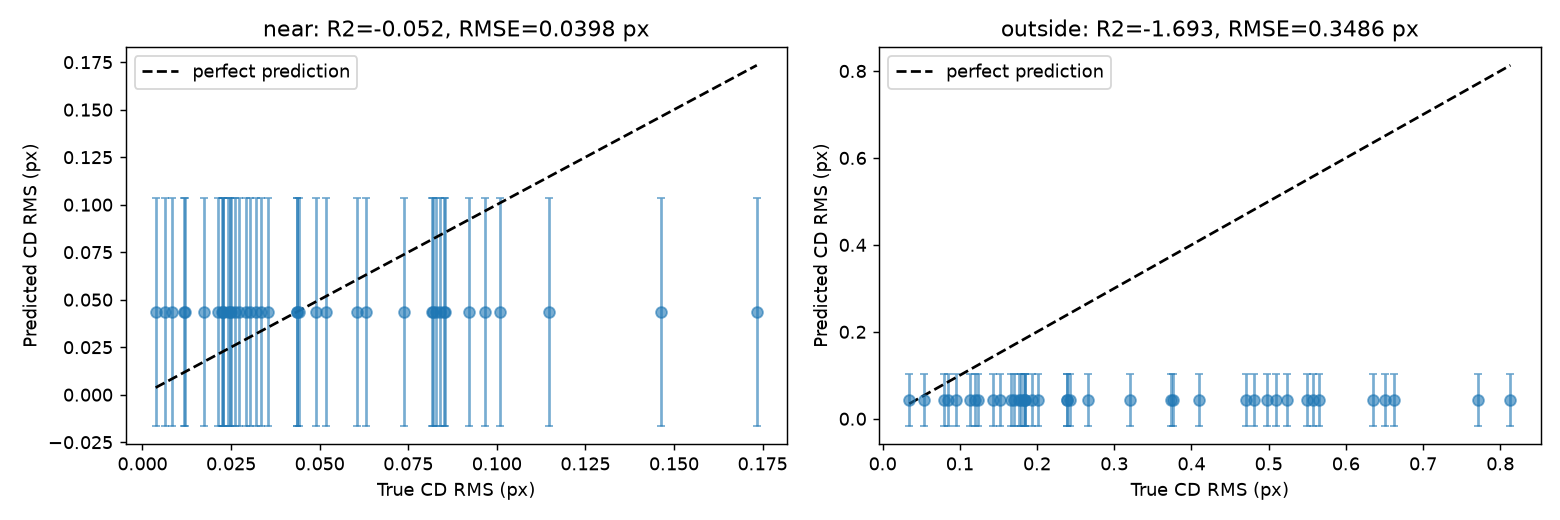

In [26]:
import matplotlib.pyplot as plt

benchmark_plot_groups = [name for name in benchmark_predictions if name != "global"]
benchmark_figure, benchmark_axes = plt.subplots(1, len(benchmark_plot_groups), figsize=(12, 4), squeeze=False)
for ax, group in zip(benchmark_axes[0], benchmark_plot_groups):
    truth = benchmark_groups[group][1]
    mean, std = benchmark_predictions[group]
    ax.errorbar(truth, mean, yerr=1.96 * std, fmt="o", alpha=0.6, capsize=2)
    endpoints = [float(min(truth.min(), mean.min())), float(max(truth.max(), mean.max()))]
    ax.plot(endpoints, endpoints, "k--", label="perfect prediction")
    metric = next(row for row in benchmark_metrics if row['samples'] == 120 and row['group'] == group)
    ax.set_title(f"{group}: R2={metric['r2']:.3f}, RMSE={metric['rmse']:.4g} px")
    ax.set_xlabel("True CD RMS (px)")
    ax.set_ylabel("Predicted CD RMS (px)")
    ax.legend()
benchmark_figure.tight_layout()
plt.show()


### 实验结论：当前默认 Surrogate 在本批 50 维陌生权重上没有学到有效预测

120 个有效训练样本下的独立评估：

| 评估区域 | 有效评估点 | RMSE（px） | 均值基线 RMSE（px） | R² | 名义 95% 区间覆盖率 |
|---|---:|---:|---:|---:|---:|
| 同训练区域、陌生向量 | 40 | 0.039796 | 0.039796 | -0.052 | 92.5% |
| 训练区域外、陌生向量 | 40 | 0.348579 | 0.348579 | -1.693 | 12.5% |
| 全域随机、仅有效 CD 点 | 4 | 5.015661 | 5.015661 | -1.327 | 0% |

24、60、120 个训练样本的拟合核长度尺度均达到下限 `1e-5`。
120 样本模型对所有评估点输出约 `0.0434222 ± 0.0305356 px`（均值 ± 标准差），
等同于预测训练 cost 均值，不能区分或排序候选；Spearman 相关性因此未定义（`nan`）。
例如同区域一个陌生点真实 RMS 为 `0.00629751 px`，另一个为 `0.096587 px`，
模型对二者的预测均为 `0.0434222 px`。

**当前默认实现不能准确预测这批陌生 50 维向量，也没有优于常数基线。**
核尺度过小使不同输入之间的相关性几乎为零，这是本次拟合结果中直接观察到的退化。
训练量从 24 增至 120 没有解除退化；这不说明高斯过程在调整训练方式后仍必然失败。
同区域覆盖率接近 95% 并不能证明模型有效，因为均值没有区分能力；远区域不确定度明显不足。

全域 20 次随机探索中 16 次出现无效交点，只有 4 个可计算的 cost。
这组误差仅供展示，不足以估计整个全域的预测精度；代理模型也不能判断交点是否合法。
本结论来自一个固定种子、固定图像和固定 gauge 的合成实验，不外推到所有问题。
若继续改进，应先仅用训练数据比较核尺度初始化/多次重启，并考虑降低有效维度；
新增调参应另设验证集，最终仍用未参与选择的新留出集评估。
